In [110]:
import numpy as np #working with matrices in python
import matplotlib.pyplot as plt  # library to plot graphs in python
from utils import *
import copy
import math
%matplotlib inline

#Create and load my data
#x_train = [distance(km), speed, age, weight(kg)]


x_train = np.array([
    [3,6,10,45],
    [10,3,20,70],
    [20,2,30,78],
    [15,1.5,40,85],
    [21,1.2, 50, 90]])

#objectif find the amount of calories burnt with the features above
y_train  = np.array([340,515,729,648,783])
w = np.array([1, 1, 1, 1], dtype=np.float64)  # Ensure w is of type float64
b = float(1)  # Bias should also be a float

alpha = 0.00025
iterations =1500



print(x_train.shape[0])
print(y_train)



5
[340 515 729 648 783]


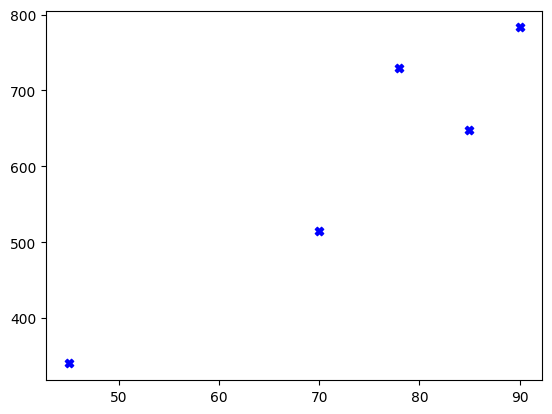

In [6]:
#create a scatter plot  to visualise my data
plt.scatter(x_train[:,3], y_train, marker ='X', c ='b')
plt.show()

In [56]:

#compute calories f(w,b) = w.x +b

def compute_calories(x_train,w,b):   
    f = np.dot(x_train, w) +b  
    return f


predicted_output = compute_calories(x_train,w,b)
print(predicted_output)
    
    




[ 65.  104.  131.  142.5 163.2]


In [70]:
#Cost Function J(w,b) = 1/(2m) sum up til m of  (predicted_output - y_train)**2

def costFunction(x_train, y_train, predicted_output):
    #length of training
    m = x_train.shape[0]

    total =0
    for i in range(m):
        total += (predicted_output[i] - y_train[i])**2

    return (0.5 * (1/m) * total)


print(costFunction(x_train, y_train, predicted_output))
    

124183.229


In [80]:
#gradient descent

def ComputeGradient(x_train, y_train, w,b, predicted_output):
    m = x_train.shape[0]
    wGradient = np.zeros_like(w, dtype=np.float64)  # Ensures wGradient is a float array
    bGradient = 0.0  # Scalar gradient for b (float)
   
    
    for i in range(m):
        wGradient += (predicted_output[i] - y_train[i])*(x_train[i])    
        bGradient += predicted_output[i] - y_train[i] 

    wGradient = (1/m)* wGradient
    bGradient = (1/m)* bGradient
    

    #error = predicted_output - y_train        # shape: (5,)
    
    #wGradient = (1/m) * np.dot(x_train.T, error)  # shape: (4,)
    #bGradient = (1/m) * np.sum(error)  

    #wGradient = (1/m) * np.dot(error, x_train)  # shape: (n,)
    #bGradient = (1/m) * np.sum(error)           # scalar
   
    return wGradient, bGradient

print(ComputeGradient(x_train, y_train, w,b, predicted_output))
        

(array([ -7498.66 ,  -1116.202, -16024.   , -37307.7  ]), np.float64(-481.86000000000007))


In [112]:
def gradientDescent(x_train, y_train, w,b, alpha, iterations):
    J_history =[]
    w_history = []
    
    
    for i in range(iterations):
        predicted_output = compute_calories(x_train,w,b)
        wGradient, bGradient = ComputeGradient(x_train, y_train, w,b, predicted_output)
        
        w = w - (alpha*wGradient)
        b = b - (alpha*bGradient)

        #save J at each iteartion in an array
        
            
        cost = costFunction(x_train, y_train, predicted_output)
        J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(iterations/10) == 0:
            w_history.append(w.copy())
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w,b, J_history, w_history
final_w, final_b, cost_history, weight_history = gradientDescent(x_train, y_train, w, b, alpha, iterations)
print("final w:",final_w)
print("final b:", final_b)
print("final cost:", cost_history[-1])
    

Iteration    0: Cost 124183.23   
Iteration  150: Cost   717.54   
Iteration  300: Cost   475.83   
Iteration  450: Cost   344.39   
Iteration  600: Cost   268.68   
Iteration  750: Cost   221.61   
Iteration  900: Cost   189.64   
Iteration 1050: Cost   166.01   
Iteration 1200: Cost   147.27   
Iteration 1350: Cost   131.63   
final w: [16.10131853  6.76751332 -1.02102266  5.29809282]
final b: 1.5785769007885717
final cost: 118.23634206234811


In [111]:
def predict(x, w, b):
    return np.dot(x, w) + b

example1 = np.array([4.2, 6.5, 21, 58])


print(predict(example1, final_w, final_b))


399.0408590727947
